In [242]:
'''
Complete Tactile Feedback code
'''
'''
Start of Train-Test results
'''

# --- Import Modules --- #
import sys, statistics, time, string, random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import pandas as pd
import pickle 
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef
from sklearn.utils.multiclass import unique_labels

sys.path.insert(0, 'C:/Users/dema2/OneDrive/Desktop/PhD/Tactile-Feedback-Repo/Reflex-Fuzzy-Network')
from RFMN import ReflexFuzzyNeuroNetwork

np.set_printoptions(threshold=5)

In [243]:
'''
Data split for Iris.csv
'''
data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\SaveModel\\Iris_feedback.csv')

data = data.iloc[:,1:]
# column names to use
# names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Label']

# read the dataset from the URL
# dataset = pd.read_csv(data, names=names)
# dataset = pd.read_csv(data)  
data.head()


,sepal-length,sepal-width,petal-length,petal-width,Label
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [244]:
# separate the independent and dependent features

# X = data.iloc[:, :-1]

X = data.iloc[:, :-4].values
# X = data.iloc[:, 1:-3].values
# X = data.iloc[:, 2:-2].values
# X = data.iloc[:, 3:-1].values


# y = data.iloc[:, 4]
print(X)


for element in np.nditer(X):
    print(element)
# print(y)

[[5.1]
 [4.9]
 [4.7]
 ...
 [6.5]
 [6.2]
 [5.9]]
5.1
4.9
4.7
4.6
5.0
5.4
4.6
5.0
4.4
4.9
5.4
4.8
4.8
4.3
5.8
5.7
5.4
5.1
5.7
5.1
5.4
5.1
4.6
5.1
4.8
5.0
5.0
5.2
5.2
4.7
4.8
5.4
5.2
5.5
4.9
5.0
5.5
4.9
4.4
5.1
5.0
4.5
4.4
5.0
5.1
4.8
5.1
4.6
5.3
5.0
7.0
6.4
6.9
5.5
6.5
5.7
6.3
4.9
6.6
5.2
5.0
5.9
6.0
6.1
5.6
6.7
5.6
5.8
6.2
5.6
5.9
6.1
6.3
6.1
6.4
6.6
6.8
6.7
6.0
5.7
5.5
5.5
5.8
6.0
5.4
6.0
6.7
6.3
5.6
5.5
5.5
6.1
5.8
5.0
5.6
5.7
5.7
6.2
5.1
5.7
6.3
5.8
7.1
6.3
6.5
7.6
4.9
7.3
6.7
7.2
6.5
6.4
6.8
5.7
5.8
6.4
6.5
7.7
7.7
6.0
6.9
5.6
7.7
6.3
6.7
7.2
6.2
6.1
6.4
7.2
7.4
7.9
6.4
6.3
6.1
7.7
6.3
6.4
6.0
6.9
6.7
6.9
5.8
6.8
6.7
6.7
6.3
6.5
6.2
5.9


In [245]:
# Create a buffer to store the last N data points
buffer_size = 149 # You can adjust the buffer_size to control the number of data points used for the median calculation. 
                # A larger buffer size will provide better noise filtering but may introduce more delay.
data_buffer = []

# Coefficient for the IIR filter (0 < a < 1)
a = 0.99

# Initialize previous output
prev_output = 0

# Function to perform IIR filtering
def iir_filter(input_data):
    global prev_output
    output = a * prev_output + (1 - a) * input_data
    prev_output = output
    return output

# Function to perform median filtering
def median_filter(data):
    data_buffer.append(data)
    if len(data_buffer) > buffer_size:
        data_buffer.pop(0)  # Remove the oldest data point

    # Calculate the median of the data in the buffer
    median_value = np.median(data_buffer)
    return median_value

def average(arr):
    total = sum(arr)
    length = len(arr)
    if length == 0:
        return None  # Handle empty array to avoid division by zero
    return total / length

In [246]:
# Simulate real-time data input (replace with your microprocessor data source)
def simulate_data_input():
    original_data = []
    filtered_data = []
    filtered_data1 = []


    for element in np.nditer(X):
        # print(element)
        data_point = element  # Simulated data
        filtered_point = median_filter(data_point)
        filtered_point1 = iir_filter(data_point)


        original_data.append(data_point)
        filtered_data.append(filtered_point)
        filtered_data1.append(filtered_point1)


        # print(f"Original Data: {data_point}, Filtered Data: {filtered_point}")
        # print(f"Original Data: {data_point}, Filtered Data1: {filtered_point1}")



    return original_data, filtered_data, filtered_data1



The minimum value is: 4.800000000000001
The maximum value is: 5.8 

[5.1, 5.0, 4.9, 4.800000000000001, 4.9, 4.95, 4.9, 4.95, 4.9, 4.9, 4.9, 4.9, 4.9, 4.85, 4.9, 4.9, 4.9, 4.95, 5.0, 5.0, 5.0, 5.05, 5.0, 5.05, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.05, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.05, 5.1, 5.05, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.15, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.2, 5.25, 5.3, 5.35, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.45, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.55, 5.6, 5.6, 5.6, 5.6, 5.6, 5.6, 5.6, 5.6, 5.6, 5.6, 5.6, 5.65, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.75, 5.8, 5.8, 5.8, 5.8]
[  0   1   2 ... 147 148 149]
The average of the meduim filter array is: 5.261333333333339
The average of the iir filter array is: 2.715982890701025


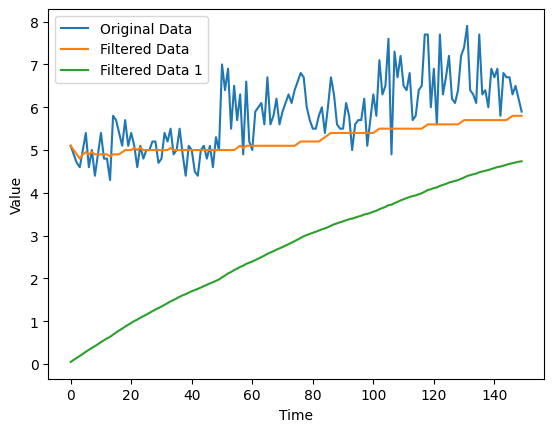

In [247]:
from numpy.polynomial import Polynomial

if __name__ == '__main__':
    original_data, filtered_data, filtered_data1 = simulate_data_input()

    filtered_data_x_axis = np.arange(len(filtered_data))


    min_value_sepal_length = np.min(filtered_data)
    max_value_sepal_length = np.max(filtered_data)
    print(f"The minimum value is: {min_value_sepal_length}")
    print(f"The maximum value is: {max_value_sepal_length} \n")

    print(filtered_data)
    print(filtered_data_x_axis)

    result = average(filtered_data)
    result1 = average(filtered_data1)

    # # Fit a polynomial of degree 1 (a straight line)
    # coeffs = np.polyfit(filtered_data_x_axis, filtered_data, 1)

    # # Create a polynomial object from the coefficients
    # trend_line = Polynomial(coeffs)

    # # Evaluate the polynomial to get the trend line values
    # trend_line_values = trend_line(filtered_data_x_axis)

    # # Print the coefficients (slope and intercept)
    # slope, intercept = coeffs
    # print(f"Slope med: {slope}, Intercept: {intercept}")


    # # Fit a polynomial of degree 1 (a straight line)
    # coeffs1 = np.polyfit(filtered_data_x_axis, filtered_data1, 1)

    # # Create a polynomial object from the coefficients
    # trend_line1 = Polynomial(coeffs1)

    # # Evaluate the polynomial to get the trend line values
    # trend_line_values1 = trend_line1(filtered_data_x_axis)

    # # Print the coefficients (slope and intercept)
    # slope1, intercept1 = coeffs1
    # print(f"Slope1 iir: {slope1}, Intercept1: {intercept1}")


    if result or result1 is not None:
        print(f"The average of the meduim filter array is: {result}")
        print(f"The average of the iir filter array is: {result1}")

    else:
        print("The array is empty.")

    # Plot original data vs. filtered data
    plt.plot(original_data, label='Original Data')
    plt.plot(filtered_data, label='Filtered Data')
    plt.plot(filtered_data1, label='Filtered Data 1')

    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()